# Stack Overflow Developer Survey Analysis — 01 Exploratory Data Analysis

An **EDA / visualization** project: who developers are and what they use — 89,184 responses to the 2023 Stack Overflow Developer Survey (country, experience, languages, remote work, pay). This notebook covers the data overview — shape, types, missing values, and univariate distributions that frame the deeper analysis in notebook 02.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
print('shape:',df.shape)
df.head()

shape: (89184, 15)


,ResponseId,MainBranch,Age,Employment,RemoteWork,EdLevel,YearsCode,YearsCodePro,DevType,Country,LanguageHaveWorkedWith,LanguageWantToWorkWith,ConvertedCompYearly,Industry,OrgSize
0,1,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",18,9,"Senior Executive (C-Suite, VP, etc.)",United States of America,HTML/CSS;JavaScript;Python,Bash/Shell (all shells);C#;Dart;Elixir;GDScrip...,285000.0,"Information Services, IT, Software Development...",2 to 9 employees
2,3,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",27,23,"Developer, back-end",United States of America,Bash/Shell (all shells);Go,Haskell;OCaml;Rust,250000.0,"Information Services, IT, Software Development...","5,000 to 9,999 employees"
3,4,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12,7,"Developer, front-end",United States of America,Bash/Shell (all shells);HTML/CSS;JavaScript;PH...,Bash/Shell (all shells);HTML/CSS;JavaScript;Ru...,156000.0,NaN,100 to 499 employees
4,5,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",6,4,"Developer, full-stack",Philippines,HTML/CSS;JavaScript;TypeScript,HTML/CSS;JavaScript;Python;Rust;TypeScript,23456.0,Other,20 to 99 employees


## 1. Structure & dtypes

In [2]:
print(df.dtypes.value_counts().to_dict())
df.info()

{dtype('O'): 13, dtype('int64'): 1, dtype('float64'): 1}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89184 entries, 0 to 89183
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ResponseId              89184 non-null  int64  
 1   MainBranch              89184 non-null  object 
 2   Age                     89184 non-null  object 
 3   Employment              87898 non-null  object 
 4   RemoteWork              73810 non-null  object 
 5   EdLevel                 87973 non-null  object 
 6   YearsCode               87435 non-null  object 
 7   YearsCodePro            66136 non-null  object 
 8   DevType                 76872 non-null  object 
 9   Country                 87973 non-null  object 
 10  LanguageHaveWorkedWith  87140 non-null  object 
 11  LanguageWantToWorkWith  80709 non-null  object 
 12  ConvertedCompYearly     48019 non-null  float64
 13  Industry                36774 non-

## 2. Missing values

In [3]:
mr=utils.missing_report(df)
print('columns with missing values:',len(mr))
print(mr.head(10).to_string())

columns with missing values: 12
                        missing    pct
Industry                  52410  58.77
ConvertedCompYearly       41165  46.16
OrgSize                   24141  27.07
YearsCodePro              23048  25.84
RemoteWork                15374  17.24
DevType                   12312  13.81
LanguageWantToWorkWith     8475   9.50
LanguageHaveWorkedWith     2044   2.29
YearsCode                  1749   1.96
Employment                 1286   1.44


## 3. Numeric distributions

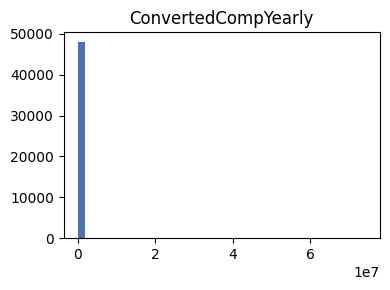

,ConvertedCompYearly
count,48019.00
mean,103110.08
std,681418.84
min,1.00
25%,43907.00
50%,74963.00
75%,121641.00
max,74351432.00


In [4]:
num=['ConvertedCompYearly']
num=[c for c in num if c in df.columns]
fig,ax=plt.subplots(1,len(num),figsize=(4*len(num),3))
ax=np.atleast_1d(ax)
for a,c in zip(ax,num):
    a.hist(df[c].dropna(),bins=40,color='#4c72b0'); a.set_title(c)
plt.tight_layout(); plt.show()
df[num].describe().round(2)

## 4. Top categories

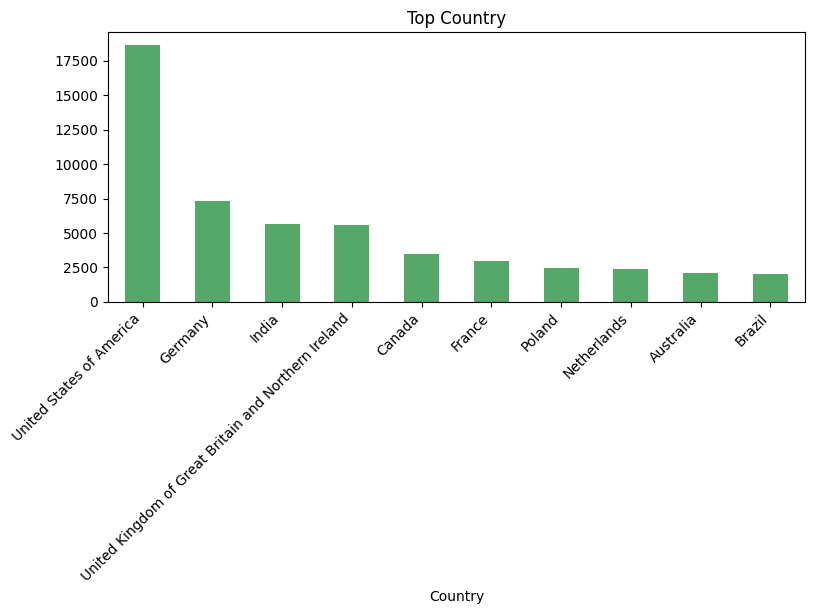

Country
United States of America                                18647
Germany                                                  7328
India                                                    5625
United Kingdom of Great Britain and Northern Ireland     5552
Canada                                                   3507
France                                                   2933
Poland                                                   2435
Netherlands                                              2383
Australia                                                2078
Brazil                                                   2042


In [5]:
vc=utils.top_counts(df['Country'],10)
fig,ax=plt.subplots(figsize=(9,3.5)); vc.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Top Country'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 5. Summary

The overview above frames the domain questions answered in notebook **02 — Analysis**, where the real insights and the headline numbers (reported in the README) come from.